# ENSO–Z500 teleconnection (DJF) — IFS-FESOM2-SR, 3-member ensemble

Regression of **DJF 500 hPa geopotential height** onto the **standardized DJF
Niño3.4 index**, for the EERIE km-scale IFS-FESOM2-SR run.

**Figure 1** — common period **1980–2014**, three panels (ens1/ens2/ens3): the
cross-member comparison of the ENSO teleconnection.

**Figure 2** — **ens1 only**, two panels: **1980–2014** (historical) vs
**2070–2097** (SSP2-4.5): how the teleconnection changes into the late century.

**DJF convention (kept from the working notebook):** shift time +1 month, then
select months [1,2,3]. After the shift, December→Jan, January→Feb, February→Mar,
so selecting [1,2,3] composites a true **DJF** mean with December drawn from the
prior calendar year. The incomplete first/last winters are dropped.

**Z500 source by member**
- **ens1**: intake catalogues (HIST `…hist-years-final.yaml`, SSP `…ssp245-years.yaml`), key `3D_monthly_0.25deg_atmos_avg`, variable `mz`, `level=500`, /9.8.
- **ens2/ens3**: gribscan zarr-JSON refs, `pl.dir/atm3d_avg.json`, same variable/level.
  Off-by-one naming: notebook **ens2** ↔ `phase2_*_ens1`, **ens3** ↔ `phase2_*_ens2`.

**Niño3.4 SST source** — ocean `avg_tos` (surface level, K→°C):
- ens1: `Phase1-HIST-FESOM` + `Phase1-SSP245-FESOM`
- ens2/ens3: `Phase2-HIST-ENS{1,2}-FESOM` + `Phase2-SSP245-ENS{1,2}-FESOM`

**Run on the HPC** where `/work/bm1344/...` lives.


In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import intake
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import t as student_t

def ifs_to_latlon(ds):
    """Reconstruct the regular lat/lon grid from IFS 'value' index."""
    return ds.rename({'value': 'latlon'}).set_index(latlon=("lat", "lon")).unstack("latlon")

def wgt_areaave(indat, latS, latN, lonW, lonE):
    """cos(lat)-weighted area average over a lat/lon box."""
    lat = indat.lat; lon = indat.lon
    if ((lonW < 0) or (lonE < 0)) and (lon.values.min() > -1):
        anm = indat.assign_coords(lon=((lon + 180) % 360 - 180))
    else:
        anm = indat
    iplat = lat.where((lat >= latS) & (lat <= latN), drop=True)
    iplon = lon.where((lon >= lonW) & (lon <= lonE), drop=True)
    wgt = np.cos(np.deg2rad(lat))
    return anm.sel(lat=iplat, lon=iplon).weighted(wgt).mean(("lon", "lat"), skipna=True)

def detrend_dim(da, dim="time", deg=1):
    coeffs = da.polyfit(dim=dim, deg=deg)
    trend = xr.polyval(da[dim], coeffs.polyfit_coefficients)
    return da - trend


In [2]:
def djf_annual_mean(da):
    """True DJF seasonal mean per winter, using the +1-month-shift convention.
       Shift time +1 month -> select months [1,2,3] (= D,J,F) -> drop the
       incomplete first winter (no December) and the incomplete last January ->
       annual mean. Returns one value per DJF season."""
    shifted = da.time.to_index() + pd.DateOffset(months=1)
    da_s = da.assign_coords(time=shifted)
    da_djf = da_s.sel(time=da_s.time.dt.month.isin([1, 2, 3]))
    first_year = da_djf.time.dt.year.min().item() + 1
    da_djf = da_djf.sel(time=da_djf.time.dt.year >= first_year)
    last_year = da_djf.time.dt.year.max().item()
    da_djf = da_djf.sel(time=~((da_djf.time.dt.year == last_year) &
                               (da_djf.time.dt.month == 1)))
    # 'Y' (older pandas) vs 'YE' (pandas >=2.2); pick whichever the env accepts
    try:
        return da_djf.resample(time="YE").mean("time")
    except (ValueError, KeyError):
        return da_djf.resample(time="Y").mean("time")


In [3]:
def xr_regression(x, y, lag_x=0, lag_y=0, dim="time", alternative="two-sided"):
    """Vectorised regression of y on x along `dim`. Returns a Dataset with
       cov, cor, r2, slope, intercept, pvalue, stderr, n."""
    if lag_x != 0:
        x = x.shift(**{dim: -lag_x}).dropna(dim=dim); x, y = xr.align(x, y)
    if lag_y != 0:
        y = y.shift(**{dim: -lag_y}).dropna(dim=dim)
    x, y = xr.align(x, y)
    n = y.notnull().sum(dim=dim)
    xmean = x.mean(dim=dim); ymean = y.mean(dim=dim)
    xstd = x.std(dim=dim);   ystd = y.std(dim=dim)
    cov = ((x - xmean) * (y - ymean)).sum(dim=dim) / n
    cor = cov / (xstd * ystd)
    r2 = cor ** 2
    slope = cov / (xstd ** 2)
    intercept = ymean - xmean * slope
    tstats = cor * np.sqrt(n - 2) / np.sqrt(1 - cor ** 2)
    stderr = slope / tstats
    if alternative == "two-sided":
        pval = student_t.sf(np.abs(tstats), n - 2) * 2
    elif alternative == "greater":
        pval = student_t.sf(tstats, n - 2)
    else:
        pval = student_t.cdf(np.abs(tstats), n - 2)
    pval = xr.DataArray(pval, dims=cor.dims, coords=cor.coords)
    return xr.merge([
        cov.rename("cov").astype(np.float32), cor.rename("cor").astype(np.float32),
        r2.rename("r2").astype(np.float32), slope.rename("slope").astype(np.float32),
        intercept.rename("intercept").astype(np.float32),
        pval.rename("pvalue").astype(np.float32),
        stderr.rename("stderr").astype(np.float32), n.rename("n").astype(np.int16),
    ])


In [4]:
# ----------------------------------------------------------------------
# Data sources
# ----------------------------------------------------------------------
NINO34 = dict(latS=-5, latN=5, lonL=190, lonR=240)   # 5S-5N, 170W-120W (0-360)

# --- Niño3.4 SST (ocean avg_tos) per member: (hist_dir, ssp_dir) ---
SST_SRC = {
    "ens1": ("/work/bm1344/a270228/Phase1-HIST-FESOM/monthly/2d/avg_tos",
             "/work/bm1344/a270228/Phase1-SSP245-FESOM/monthly/2d/avg_tos"),
    "ens2": ("/work/bm1344/a270228/Phase2-HIST-ENS1-FESOM/monthly/2d/avg_tos",
             "/work/bm1344/a270228/Phase2-SSP245-ENS1-FESOM/monthly/2d/avg_tos"),
    "ens3": ("/work/bm1344/a270228/Phase2-HIST-ENS2-FESOM/monthly/2d/avg_tos",
             "/work/bm1344/a270228/Phase2-SSP245-ENS2-FESOM/monthly/2d/avg_tos"),
}

# --- Z500 atmosphere source per member ---
# ens1 via intake catalogues; ens2/ens3 via gribscan zarr-JSON references.
CAT_HIST = "/work/bm1344/a270228/tco1279-ng5-eerie-production-hist-years-final.yaml"
CAT_SSP  = "/work/bm1344/a270228/tco1279-ng5-eerie-production-ssp245-years.yaml"
ATMKEY   = "3D_monthly_0.25deg_atmos_avg"

Z500_REF = {  # ens2/ens3: (hist_json, ssp_json)
    "ens2": ("reference::/work/bm1344/a270228/phase2_hist_ens1/gribscan_1m_REGULARLL/jsons.1975-2014/pl.dir/atm3d_avg.json",
             "reference::/work/bm1344/a270228/phase2_ssp245_ens1/gribscan_1m_REGULARLL/jsons.2015-2030/pl.dir/atm3d_avg.json"),
    "ens3": ("reference::/work/bm1344/a270228/phase2_hist_ens2/gribscan_1m_REGULARLL/jsons.1975-2014/pl.dir/atm3d_avg.json",
             "reference::/work/bm1344/a270228/phase2_ssp245_ens2/gribscan_1m_REGULARLL/jsons.2015-2030/pl.dir/atm3d_avg.json"),
}

G = 9.8   # divide geopotential mz by g to get geopotential height (m)


In [5]:
# ----------------------------------------------------------------------
# Loaders
# ----------------------------------------------------------------------
def load_sst(folder, time_slice):
    ds = xr.open_mfdataset(f"{folder}/avg_tos_*.nc")
    da = ds["avg_tos"]
    if da.ndim == 4:
        da = da[:, 0, :, :]
    return (da - 273.15).sel(time=time_slice)

def nino34_std(hist_dir, ssp_dir, time_slice, box=NINO34):
    """Standardized DJF Niño3.4 index over `time_slice`. Loads HIST and/or SSP
       as needed so the slice is covered; detrends and standardizes on the slice."""
    y0 = int(time_slice.start); y1 = int(time_slice.stop)
    parts = []
    if y0 <= 2014:
        parts.append(load_sst(hist_dir, slice(str(y0), str(min(y1, 2014)))))
    if y1 >= 2015:
        parts.append(load_sst(ssp_dir, slice(str(max(y0, 2015)), str(y1))))
    sst = xr.concat(parts, dim="time").sortby("time") if len(parts) > 1 else parts[0]
    nino = wgt_areaave(sst, box["latS"], box["latN"], box["lonL"], box["lonR"])
    nino_djf = djf_annual_mean(nino)
    nino_dt = detrend_dim(nino_djf, dim="time")
    return (nino_dt - nino_dt.mean()) / nino_dt.std()

# ens1 Z500 from intake (open once, reuse)
def open_ens1_z500_catalogs():
    cat_h = intake.open_catalog(CAT_HIST)
    cat_s = intake.open_catalog(CAT_SSP)
    dh = ifs_to_latlon(cat_h[ATMKEY].to_dask())
    dssp = ifs_to_latlon(cat_s[ATMKEY].to_dask())
    return dh, dssp

def z500_djf_detrended_ens1(ds_atmos, time_slice):
    z = ds_atmos["mz"].sel(time=time_slice, level=500) / G
    return detrend_dim(djf_annual_mean(z), dim="time")

def z500_djf_detrended_ref(json_ref, time_slice):
    ds = xr.open_zarr(json_ref, consolidated=False)
    ds = ifs_to_latlon(ds)
    # NOTE: if the 3D ensemble files name the level coord differently
    # (e.g. 'plev' in Pa), change the next line, e.g. .sel(plev=50000).
    z = ds["mz"].sel(time=time_slice, level=500) / G
    return detrend_dim(djf_annual_mean(z), dim="time")


## Figure 1 — common-period (1980–2014) teleconnection, three members

Regression of DJF Z500 on the standardized DJF Niño3.4 index, computed
identically for ens1/ens2/ens3 over the shared historical window 1980–2014
(35 winters; the first DJF is dropped by the shift convention, leaving 34).

In [6]:
COMMON = slice("1980", "2014")

# ens1 catalogues (open once)
dsh_ens1, dssp_ens1 = open_ens1_z500_catalogs()

reg_common = {}
for m in ["ens1", "ens2", "ens3"]:
    nino_std = nino34_std(SST_SRC[m][0], SST_SRC[m][1], COMMON)
    if m == "ens1":
        z500_dt = z500_djf_detrended_ens1(dsh_ens1, COMMON)
    else:
        z500_dt = z500_djf_detrended_ref(Z500_REF[m][0], COMMON)
    reg = xr_regression(nino_std, z500_dt, dim="time")
    reg_common[m] = reg
    print(f"{m}: regression done, n winters = {int(reg['n'].max())}")


ens1: regression done, n winters = 34
ens2: regression done, n winters = 34
ens3: regression done, n winters = 34


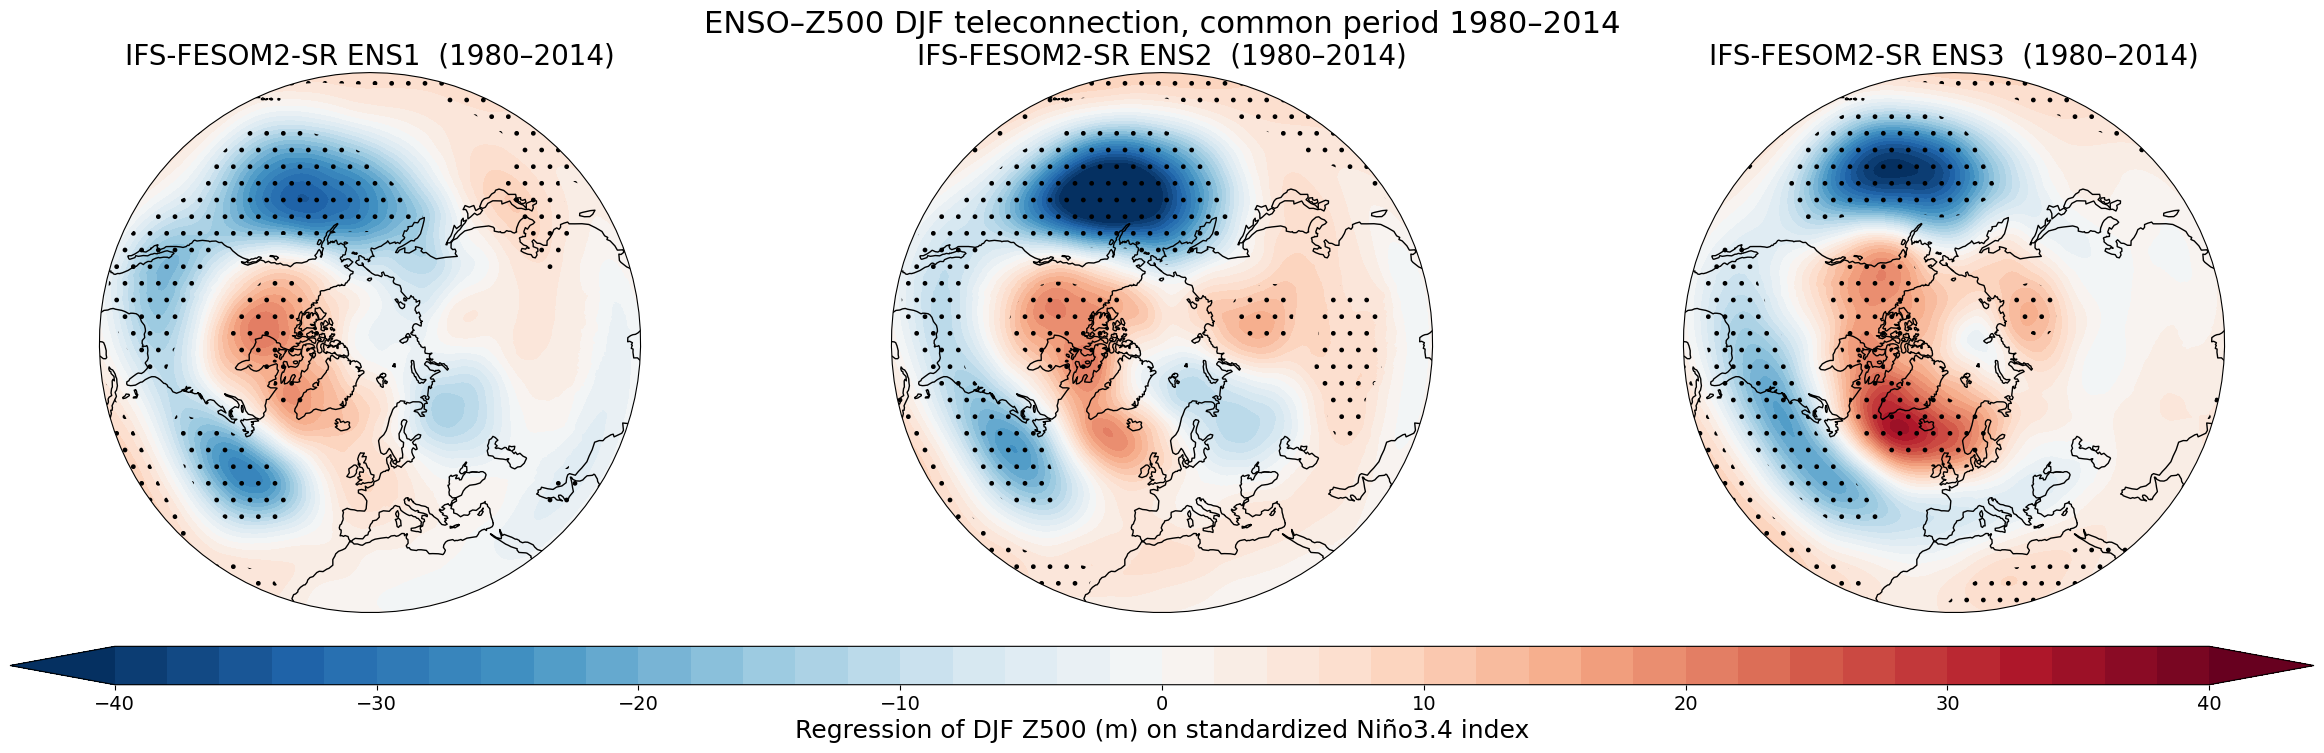

In [7]:
def polar_panel(ax, slope, pval, title, vlim=40):
    ax.set_extent([-180, 180, 20, 90], crs=ccrs.PlateCarree())
    theta = np.linspace(0, 2 * np.pi, 100)
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    ax.set_boundary(mpath.Path(verts * 0.5 + [0.5, 0.5]), transform=ax.transAxes)
    cf = slope.plot.contourf(ax=ax, vmin=-vlim, vmax=vlim, levels=41, extend="both",
                             cmap="RdBu_r", add_colorbar=False,
                             transform=ccrs.PlateCarree(), robust=True)
    (1 - pval).plot.contourf(ax=ax, levels=[0, 0.95, 1], hatches=["", "."],
                             alpha=0, transform=ccrs.PlateCarree(),
                             add_colorbar=False)
    ax.coastlines(linewidth=1.0)
    ax.add_feature(cfeature.LAND, facecolor="none", edgecolor="k", linewidth=0.4)
    ax.set_title(title, fontsize=20)
    return cf

fig = plt.figure(figsize=(24, 9))
positions = [[0.02, 0.15, 0.30, 0.75],
             [0.35, 0.15, 0.30, 0.75],
             [0.68, 0.15, 0.30, 0.75]]
titles = {"ens1": "ENS1", "ens2": "ENS2", "ens3": "ENS3"}
axes = []
for pos, m in zip(positions, ["ens1", "ens2", "ens3"]):
    ax = fig.add_axes(pos, projection=ccrs.NorthPolarStereo())
    cf = polar_panel(ax, reg_common[m].slope, reg_common[m].pvalue,
                     f"IFS-FESOM2-SR {titles[m]}  (1980–2014)")
    axes.append(ax)
cb = plt.colorbar(cf, ax=axes, orientation="horizontal", pad=0.05, aspect=60)
cb.set_label("Regression of DJF Z500 (m) on standardized Niño3.4 index", fontsize=18)
cb.ax.tick_params(labelsize=14)
fig.suptitle("ENSO–Z500 DJF teleconnection, common period 1980–2014",
             fontsize=22, y=0.97)
fig.savefig("Z500_DJF_ENSO_teleconnection_3members_1980-2014.png",
            bbox_inches="tight", dpi=300)
plt.show()


## Figure 2 — ens1 only: historical (1980–2014) vs late century (2070–2097)

Same regression for ens1, contrasting the historical window with a late-SSP2-4.5
window to show how the ENSO–Z500 teleconnection changes. The 2070–2097 Z500 comes
from the SSP catalogue; the SST index for that window also comes from the SSP run.

ens1 hist winters: 34 | late winters: 27


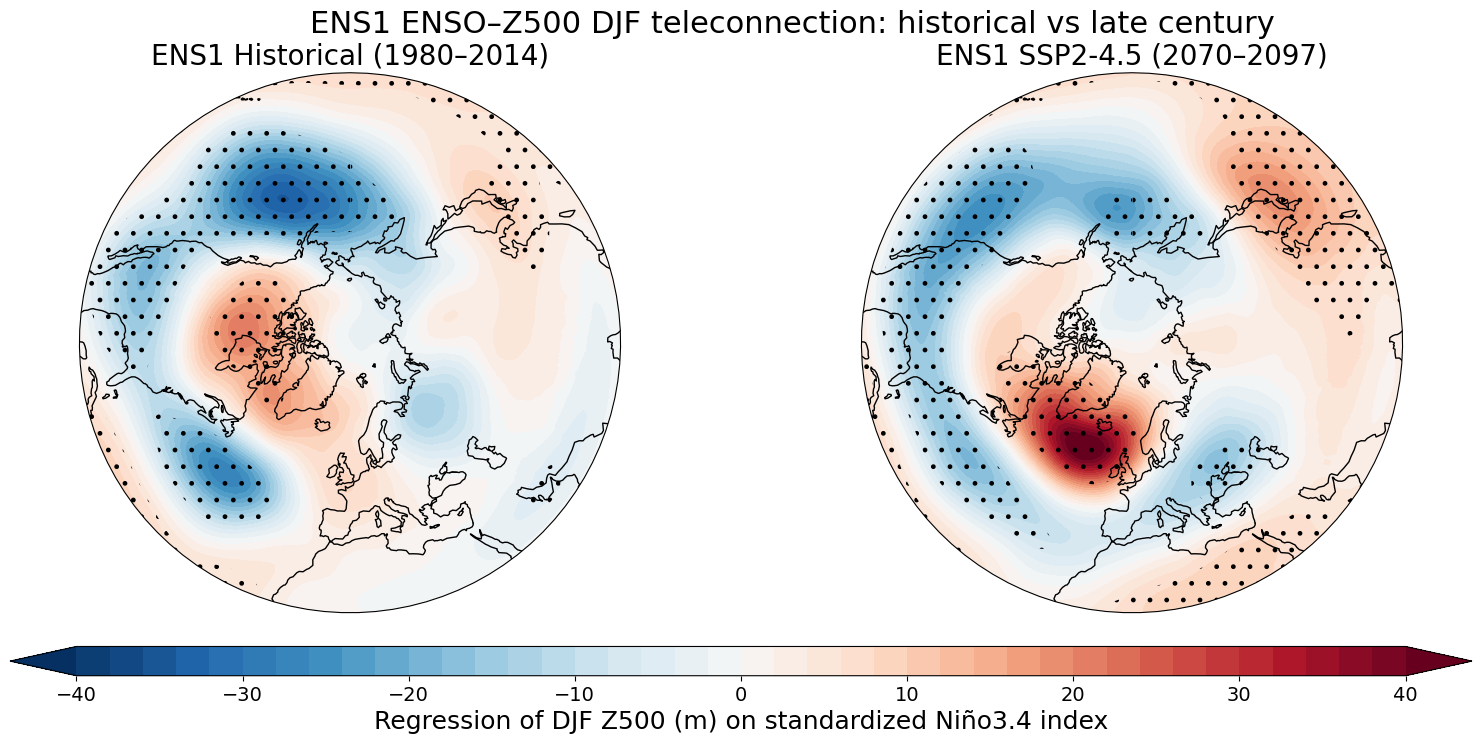

In [11]:

# ============================================================
# Figure 2 (standalone, self-contained) — ens1: hist 1980–2014 vs late century
# Defines _select_z500 locally so it doesn't depend on other cells having run.
# Still reuses: nino34_std, djf_annual_mean, detrend_dim, xr_regression,
#               polar_panel, ifs_to_latlon, SST_SRC, G, COMMON, dsh_ens1
# ============================================================

def _select_z500(ds_atmos, time_slice):
    """Select mz at 500 hPa over a time slice, with clear diagnostics.
       Handles 'level' in hPa or 'plev' in Pa."""
    if "mz" not in ds_atmos:
        raise KeyError(f"'mz' not in dataset; vars: {list(ds_atmos.data_vars)[:20]}")
    z = ds_atmos["mz"]
    yrs = np.unique(z["time"].dt.year.values)
    y0, y1 = int(time_slice.start), int(time_slice.stop)
    if (yrs.min() > y1) or (yrs.max() < y0):
        raise ValueError(f"Requested {y0}-{y1} but 'mz' covers {yrs.min()}-{yrs.max()}. No overlap.")
    z = z.sel(time=time_slice)
    n_yrs = np.unique(z["time"].dt.year.values).size if z["time"].size else 0
    if n_yrs < 5:
        raise ValueError(f"slice {y0}-{y1} gave only {n_yrs} year(s); 'mz' covers {yrs.min()}-{yrs.max()}.")
    if "level" in z.coords:
        z = z.sel(level=500)
    elif "plev" in z.coords:
        z = z.sel(plev=50000)
    else:
        raise KeyError(f"no 'level'/'plev' coord; coords: {list(z.coords)}")
    return z / G

def z500_djf_detrended_ens1(ds_atmos, time_slice):
    return detrend_dim(djf_annual_mean(_select_z500(ds_atmos, time_slice)), dim="time")

def z500_djf_detrended_ref_open(json_ref, time_slice):
    ds = ifs_to_latlon(xr.open_zarr(json_ref, consolidated=False))
    return detrend_dim(djf_annual_mean(_select_z500(ds, time_slice)), dim="time")

# ens1 SSP 3D atmosphere — phase1 gribscan reference (covers to 2098)
Z500_REF_ENS1_SSP = ("reference::/work/bm1344/a270228/phase1_ssp245/"
                     "gribscan_1m_REGULARLL/jsons.2015-2098/pl.dir/atm3d_avg.json")
LATE = slice("2070", "2097")

# historical (intake catalog already open as dsh_ens1)
nino_hist = nino34_std(SST_SRC["ens1"][0], SST_SRC["ens1"][1], COMMON)
z500_hist = z500_djf_detrended_ens1(dsh_ens1, COMMON)
reg_ens1_hist = xr_regression(nino_hist, z500_hist, dim="time")

# late century (gribscan 3D reference)
nino_late = nino34_std(SST_SRC["ens1"][0], SST_SRC["ens1"][1], LATE)
z500_late = z500_djf_detrended_ref_open(Z500_REF_ENS1_SSP, LATE)
reg_ens1_late = xr_regression(nino_late, z500_late, dim="time")

print("ens1 hist winters:", int(reg_ens1_hist['n'].max()),
      "| late winters:", int(reg_ens1_late['n'].max()))

# plot
fig = plt.figure(figsize=(17, 9))
positions = [[0.04, 0.15, 0.40, 0.75], [0.50, 0.15, 0.40, 0.75]]
panels = [("ENS1 Historical (1980–2014)", reg_ens1_hist),
          ("ENS1 SSP2-4.5 (2070–2097)", reg_ens1_late)]
axes = []
for pos, (title, reg) in zip(positions, panels):
    ax = fig.add_axes(pos, projection=ccrs.NorthPolarStereo())
    cf = polar_panel(ax, reg.slope, reg.pvalue, title)
    axes.append(ax)
cb = plt.colorbar(cf, ax=axes, orientation="horizontal", pad=0.05, aspect=50)
cb.set_label("Regression of DJF Z500 (m) on standardized Niño3.4 index", fontsize=18)
cb.ax.tick_params(labelsize=14)
fig.suptitle("ENS1 ENSO–Z500 DJF teleconnection: historical vs late century",
             fontsize=22, y=0.97)
fig.savefig("Z500_DJF_ENSO_teleconnection_ENS1_hist_vs_2070-2097.png",
            bbox_inches="tight", dpi=300)
plt.show()

In [ ]:
fig = plt.figure(figsize=(17, 9))
positions = [[0.04, 0.15, 0.40, 0.75], [0.50, 0.15, 0.40, 0.75]]
panels = [("ENS1 Historical (1980–2014)", reg_ens1_hist),
          ("ENS1 SSP2-4.5 (2070–2097)", reg_ens1_late)]
axes = []
for pos, (title, reg) in zip(positions, panels):
    ax = fig.add_axes(pos, projection=ccrs.NorthPolarStereo())
    cf = polar_panel(ax, reg.slope, reg.pvalue, title)
    axes.append(ax)
cb = plt.colorbar(cf, ax=axes, orientation="horizontal", pad=0.05, aspect=50)
cb.set_label("Regression of DJF Z500 (m) on standardized Niño3.4 index", fontsize=18)
cb.ax.tick_params(labelsize=14)
fig.suptitle("ENS1 ENSO–Z500 DJF teleconnection: historical vs late century",
             fontsize=22, y=0.97)
fig.savefig("Z500_DJF_ENSO_teleconnection_ENS1_hist_vs_2070-2097.png",
            bbox_inches="tight", dpi=300)
plt.show()


### Notes / likely tweak points
- **Level coordinate for ens2/ens3.** `z500_djf_detrended_ref` selects `mz` at
  `level=500`. If the 3D gribscan files name it `plev` in Pa, change that one line
  to `.sel(plev=50000)`. Everything else is identical to the ens1 path.
- **Colour limits.** `vlim=40` m matches the working notebook's polar plots; raise
  it if late-century slopes saturate.
- **Window length.** 1980–2014 yields ~34 DJF seasons after the shift drops the
  first winter; 2070–2097 yields ~27. The regression `n` is printed so you can
  confirm the significance test has sensible degrees of freedom.